In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

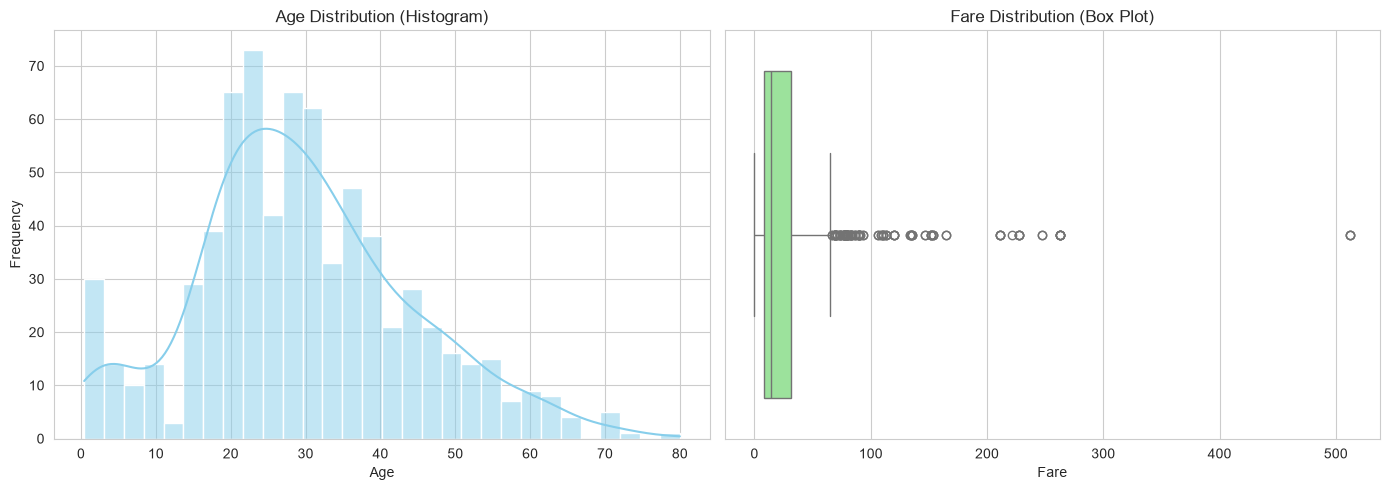

In [7]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['age'].dropna(), kde=True, bins=30, color='skyblue', ax=axes[0])
axes[0].set_title('Age Distribution (Histogram)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
sns.boxplot(x=df['fare'], color='lightgreen', ax=axes[1])
axes[1].set_title('Fare Distribution (Box Plot)')
axes[1].set_xlabel('Fare')

plt.tight_layout()
plt.show()

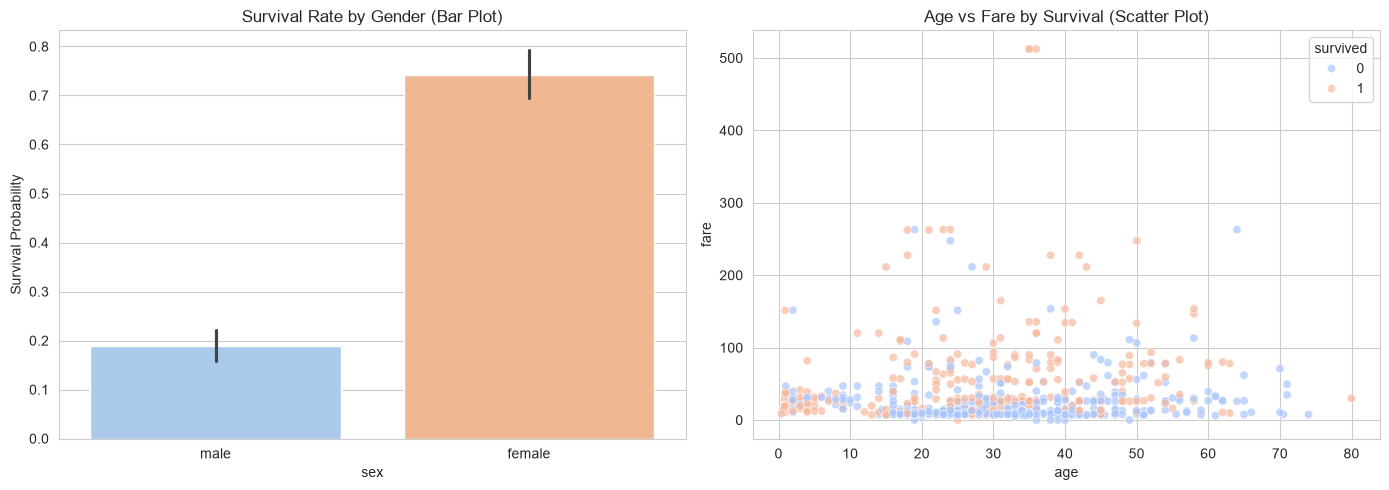

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='sex', y='survived', data=df, palette='pastel', ax=axes[0])
axes[0].set_title('Survival Rate by Gender (Bar Plot)')
axes[0].set_ylabel('Survival Probability')
sns.scatterplot(x='age', y='fare', hue='survived', data=df, palette='coolwarm', alpha=0.7, ax=axes[1])
axes[1].set_title('Age vs Fare by Survival (Scatter Plot)')

plt.tight_layout()
plt.show()

In [10]:
cols_to_drop = ['deck', 'alive', 'class', 'who', 'adult_male', 'embark_town']
df_clean = df.drop(columns=cols_to_drop)
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
print("Missing values AFTER imputation:")
print(df_clean.isnull().sum())

Missing values AFTER imputation:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


In [11]:
df_clean['sex'] = df_clean['sex'].map({'male': 0, 'female': 1})
df_clean['alone'] = df_clean['alone'].astype(int)
df_clean = pd.get_dummies(df_clean, columns=['embarked'], drop_first=True)
print(df_clean.head())

   survived  pclass  sex   age  sibsp  parch     fare  alone  embarked_Q  \
0         0       3    0  22.0      1      0   7.2500      0       False   
1         1       1    1  38.0      1      0  71.2833      0       False   
2         1       3    1  26.0      0      0   7.9250      1       False   
3         1       1    1  35.0      1      0  53.1000      0       False   
4         0       3    0  35.0      0      0   8.0500      1       False   

   embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
X = df_clean.drop('survived', axis=1)
y = df_clean['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}\n")

Training data size: (712, 9)
Testing data size: (179, 9)



In [13]:
lgbm_base = LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 hides LightGBM warnings
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
lgbm_base.fit(X_train, y_train)
xgb_base.fit(X_train, y_train)
lgbm_preds = lgbm_base.predict(X_test)
xgb_preds = xgb_base.predict(X_test)

In [14]:
def print_metrics(model_name, y_true, y_pred):
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}\n")
print_metrics("LightGBM (Base)", y_test, lgbm_preds)
print_metrics("XGBoost (Base)", y_test, xgb_preds)

--- LightGBM (Base) Performance ---
Accuracy  : 0.8268
Precision : 0.7945
Recall    : 0.7838
F1-Score  : 0.7891

--- XGBoost (Base) Performance ---
Accuracy  : 0.8045
Precision : 0.7746
Recall    : 0.7432
F1-Score  : 0.7586



In [15]:
from sklearn.model_selection import GridSearchCV
lgbm_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
print("Tuning LightGBM... (please wait a few seconds)")
lgbm_grid = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1), lgbm_params, cv=5, scoring='accuracy')
lgbm_grid.fit(X_train, y_train)
print(f"Best LightGBM Parameters: {lgbm_grid.best_params_}")
lgbm_tuned_preds = lgbm_grid.predict(X_test)
print_metrics("LightGBM (Tuned)", y_test, lgbm_tuned_preds)

Tuning LightGBM... (please wait a few seconds)
Best LightGBM Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
--- LightGBM (Tuned) Performance ---
Accuracy  : 0.8045
Precision : 0.8000
Recall    : 0.7027
F1-Score  : 0.7482



In [16]:
xgb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
print("Tuning XGBoost... (please wait a few seconds)")
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), xgb_params, cv=5, scoring='accuracy')
xgb_grid.fit(X_train, y_train)
print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")
xgb_tuned_preds = xgb_grid.predict(X_test)
print_metrics("XGBoost (Tuned)", y_test, xgb_tuned_preds)

Tuning XGBoost... (please wait a few seconds)
Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
--- XGBoost (Tuned) Performance ---
Accuracy  : 0.8212
Precision : 0.8500
Recall    : 0.6892
F1-Score  : 0.7612



### Comparative Analysis: LightGBM vs. XGBoost on Titanic Dataset

#### 1. Performance Overview
* **LightGBM:** Performed exceptionally well on default settings (Base Accuracy: 82.68%). However, after hyperparameter tuning (`learning_rate: 0.1`, `max_depth: 3`, `n_estimators: 50`), its accuracy settled at 80.45%. This indicates that LightGBM's default parameters were already highly optimal for this specific dataset size, and restricting the tree depth reduced its slightly overfitted base performance.
* **XGBoost:** The base model started with an accuracy of 80.45%. After applying hyperparameter tuning (`learning_rate: 0.1`, `max_depth: 3`, `n_estimators: 100`), it successfully optimized its learning path, achieving a superior **Accuracy of 82.12%** and a highly impressive **Precision of 85.00%**.

#### 2. Strengths and Weaknesses
* **XGBoost:**
  * *Strengths:* Highly robust and responds excellently to hyperparameter tuning. It achieved the highest precision (85%), meaning when it predicts a passenger survived, it is extremely reliable. It handles complex non-linear relationships very well.
  * *Weaknesses:* Computationally heavier and takes slightly longer to train/tune compared to LightGBM.
* **LightGBM:**
  * *Strengths:* Extremely fast training speed (due to its histogram-based approach) and excellent out-of-the-box (base) performance. Great for handling massive datasets.
  * *Weaknesses:* Can be prone to overfitting on smaller datasets (like Titanic) if parameters like tree depth are not strictly managed.

#### 3. Practical Implications
In real-world classification scenarios, the choice of evaluation metric depends on the business problem. If the goal is strictly minimizing false positives (e.g., confidently identifying actual survivors without giving false hope), XGBoost’s high precision makes it the ideal choice. While LightGBM offers speed, for this specific dataset and tuning grid, **XGBoost is the winning algorithm** due to its post-tuning accuracy and stability.